# eX2. Построение вычисления детерминанта (матрица 2×2)

**Цель:** наглядно показать, как вычисляется детерминант матрицы 2×2 и как он связан с площадью образа единичного квадрата.

**Формула:** для матрицы  
$$A = \begin{pmatrix} a & b \\ c & d \end{pmatrix}$$  
детерминант  
$$\det A = ad - bc.$$

**Геометрический смысл:** столбцы матрицы — это образы базисных векторов $\mathbf{e}_1$, $\mathbf{e}_2$. Параллелограмм с вершинами $\mathbf{0}$, $\mathbf{v}_1$, $\mathbf{v}_1+\mathbf{v}_2$, $\mathbf{v}_2$ имеет (ориентированную) площадь, равную $|\det A|$.

Ниже: единичный квадрат и его образ под действием матрицы в трёх случаях — без смещения (квадрат/масштаб), со смещением по одной оси, со смещением по обеим осям.

In [53]:
%matplotlib inline
# Чёткий рендеринг на дисплеях с высоким DPI (Retina и др.):
%config InlineBackend.figure_format = 'retina'

import numpy as np
import matplotlib.pyplot as plt

def det2(A):
    """Детерминант матрицы 2×2: det([[a,b],[c,d]]) = a*d - b*c"""
    return A[0, 0] * A[1, 1] - A[0, 1] * A[1, 0]

def plot_unit_square_and_image(A, title="", ax=None):
    """Рисует единичный квадрат и его образ под действием матрицы A."""
    if ax is None:
        fig, ax = plt.subplots(1, 1, figsize=(6, 5))
    # Вершины единичного квадрата (с замыканием)
    square = np.array([[0, 0], [1, 0], [1, 1], [0, 1], [0, 0]])
    image = (A @ square.T).T
    ax.plot(square[:, 0], square[:, 1], 'b-o', label='Единичный квадрат', markersize=6)
    ax.plot(image[:, 0], image[:, 1], 'r-s', label='Образ под A', markersize=6)
    ax.set_aspect('equal')
    ax.axhline(0, color='k', linewidth=0.5)
    ax.axvline(0, color='k', linewidth=0.5)
    ax.legend()
    ax.set_title(title)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    return ax

---
## Вывод формулы $\det A = ad - bc$ (от определения площади)

Мы **не принимаем** формулу как данность — выведем её из геометрического определения площади параллелограмма.

**Шаг 1.** Площадь параллелограмма со сторонами $\mathbf{v}_1 = (a,c)$ и $\mathbf{v}_2 = (b,d)$ по определению:
$$S = \text{основание} \times \text{высота} = |\mathbf{v}_1| \cdot h.$$

**Шаг 2.** Высота $h$ — это (ориентированное) расстояние от конца $\mathbf{v}_2$ до прямой, натянутой на $\mathbf{v}_1$. Оно равно длине проекции $\mathbf{v}_2$ на направление, **перпендикулярное** $\mathbf{v}_1$.

**Шаг 3.** Вектор, перпендикулярный $\mathbf{v}_1 = (a, c)$, можно взять в виде $\mathbf{n}_\perp = (-c, a)$ (поворот на 90°). Его длина $|\mathbf{n}_\perp| = \sqrt{c^2 + a^2} = |\mathbf{v}_1|$. Единичный перпендикуляр: $\displaystyle \frac{(-c, a)}{|\mathbf{v}_1|}$.

**Почему высота со знаком = $\mathbf{v}_2 \cdot \mathbf{n}$?** Вектор $\mathbf{v}_2$ можно разложить на две составляющие: вдоль прямой по $\mathbf{v}_1$ и перпендикулярно ей (вдоль $\mathbf{n}$). Составляющая вдоль $\mathbf{n}$ — это вектор «в высоту»; его длина и есть высота. Скалярное произведение $\mathbf{v}_2 \cdot \mathbf{n}$ при единичном $\mathbf{n}$ как раз равно длине проекции $\mathbf{v}_2$ на направление $\mathbf{n}$, т.е. этой высоте (со знаком в зависимости от того, с какой стороны прямой лежит $\mathbf{v}_2$).

**Шаг 4.** (Ориентированная) высота — это скалярное произведение $\mathbf{v}_2$ на единичный перпендикуляр:
$$h_{\text{знак}} = \mathbf{v}_2 \cdot \frac{(-c, a)}{|\mathbf{v}_1|} = \frac{(b,d)\cdot(-c,a)}{|\mathbf{v}_1|} = \frac{-bc + ad}{|\mathbf{v}_1|} = \frac{ad - bc}{|\mathbf{v}_1|}.$$

**Шаг 5.** Площадь (по модулю): $S = |\mathbf{v}_1| \cdot |h_{\text{знак}}| = |\mathbf{v}_1| \cdot \dfrac{|ad - bc|}{|\mathbf{v}_1|} = \mathbf{|ad - bc|}$.

Итого: **площадь параллелограмма = $|ad - bc|$**, то есть формула $\det A = ad - bc$ получается из определения площади (основание × высота) и выражения высоты через скалярное произведение с перпендикуляром $(-c,a)$. Числа $ad$ и $bc$ появляются именно из этого скалярного произведения $(b,d)\cdot(-c,a) = ad - bc$.

Ниже — картинка с параллелограммом, основанием, высотой и подписью получившейся площади.

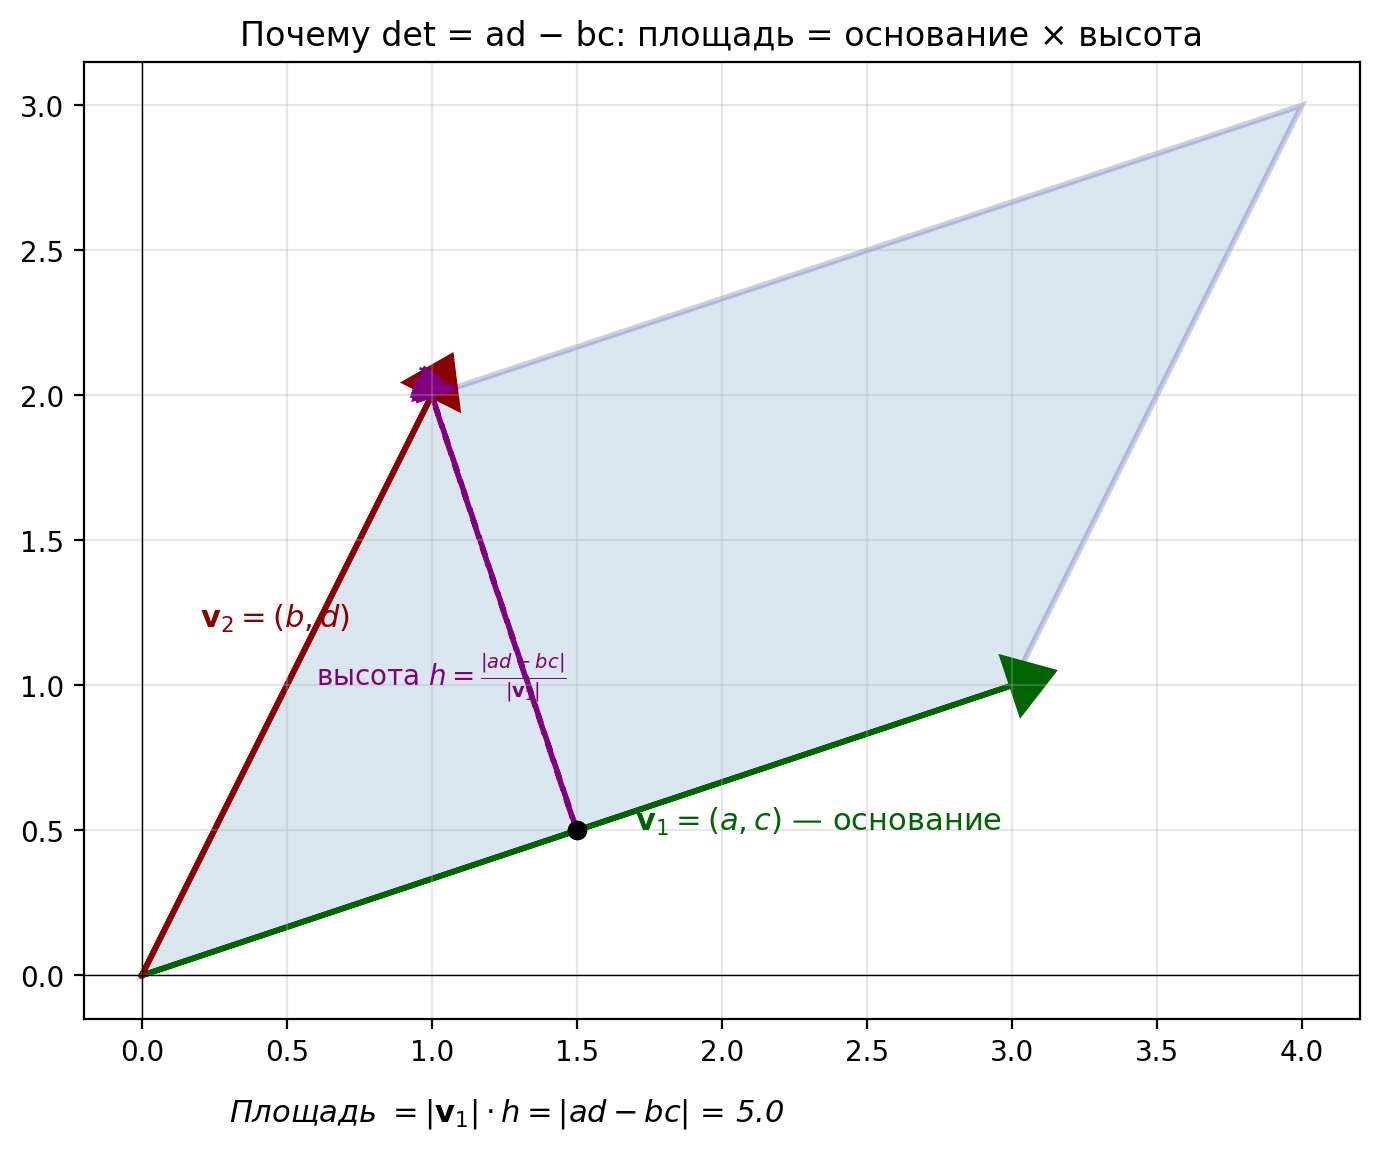

In [54]:
# Геометрический вывод формулы det = ad - bc (базис × высота)
a, b, c, d = 3.0, 1.0, 1.0, 2.0
v1 = np.array([a, c])
v2 = np.array([b, d])
det_val = a*d - b*c
base_len = np.linalg.norm(v1)

# Нога перпендикуляра от v2 на прямую по v1: t*v1, где t = (v2·v1)/|v1|²
t = np.dot(v2, v1) / (base_len**2)
foot = t * v1
height_vec = v2 - foot
height_len = np.linalg.norm(height_vec)  # = |det|/base_len

fig, ax = plt.subplots(1, 1, figsize=(7, 6))
# Параллелограмм
para = np.array([[0, 0], v1, v1+v2, v2, [0, 0]])
ax.fill(para[:, 0], para[:, 1], alpha=0.2, color='steelblue', edgecolor='navy', linewidth=2)
# Векторы-столбцы
ax.arrow(0, 0, v1[0], v1[1], head_width=0.2, head_length=0.15, fc='darkgreen', ec='darkgreen', linewidth=2)
ax.arrow(0, 0, v2[0], v2[1], head_width=0.2, head_length=0.15, fc='darkred', ec='darkred', linewidth=2)
# Высота (перпендикуляр от v2 к прямой по v1)
ax.arrow(foot[0], foot[1], height_vec[0], height_vec[1], head_width=0.15, head_length=0.1, fc='purple', ec='purple', linewidth=2, linestyle='--')
ax.plot([foot[0], foot[0]], [foot[1], foot[1]], 'ko', markersize=6)
# Подписи
ax.text(v1[0]/2 + 0.2, v1[1]/2, r'$\mathbf{v}_1 = (a, c)$ — основание', fontsize=11, color='darkgreen')
ax.text(v2[0]/2 - 0.3, v2[1]/2 + 0.2, r'$\mathbf{v}_2 = (b, d)$', fontsize=11, color='darkred')
ax.text(foot[0]/2 + height_vec[0]/2 + 0.1, foot[1]/2 + height_vec[1]/2, r'высота $h = \frac{|ad-bc|}{|\mathbf{v}_1|}$', fontsize=10, color='purple')
ax.text(0.3, -0.5, r'Площадь $= |\mathbf{v}_1| \cdot h = |ad - bc|$ = ' + str(round(abs(det_val), 2)), fontsize=11, style='italic')
ax.set_aspect('equal')
ax.axhline(0, color='k', linewidth=0.5)
ax.axvline(0, color='k', linewidth=0.5)
ax.grid(True, alpha=0.3)
ax.set_title('Почему det = ad − bc: площадь = основание × высота')
plt.tight_layout()
plt.show()

**Простой пример-аналогия (то же самое, только база — ось $x$).**  
В декартовой плоскости возьмём «базу» по оси $x$ — направление вектора $(1, 0)$. Единичный перпендикуляр к нему — это $(0, 1)$ (ось $y$). Для любого вектора $\mathbf{v} = (x, y)$ «высота» над осью $x$ считается так же, как выше: скалярное произведение с единичным перпендикуляром:
$$\mathbf{v} \cdot (0, 1) = x\cdot 0 + y\cdot 1 = y.$$
То есть получается просто координата $y$. **Пример:** вектор $(2, 3)$, тогда $(2,3)\cdot(0,1) = 3$ — это и есть «высота» (длина перпендикуляра на ось $x$). Общая формула «высота = $\mathbf{v}_2 \cdot \mathbf{n}$» — та же идея, только база не горизонтальная, а наклонная (вектор $\mathbf{v}_1$), и единичный перпендикуляр к ней — $\mathbf{n}$.

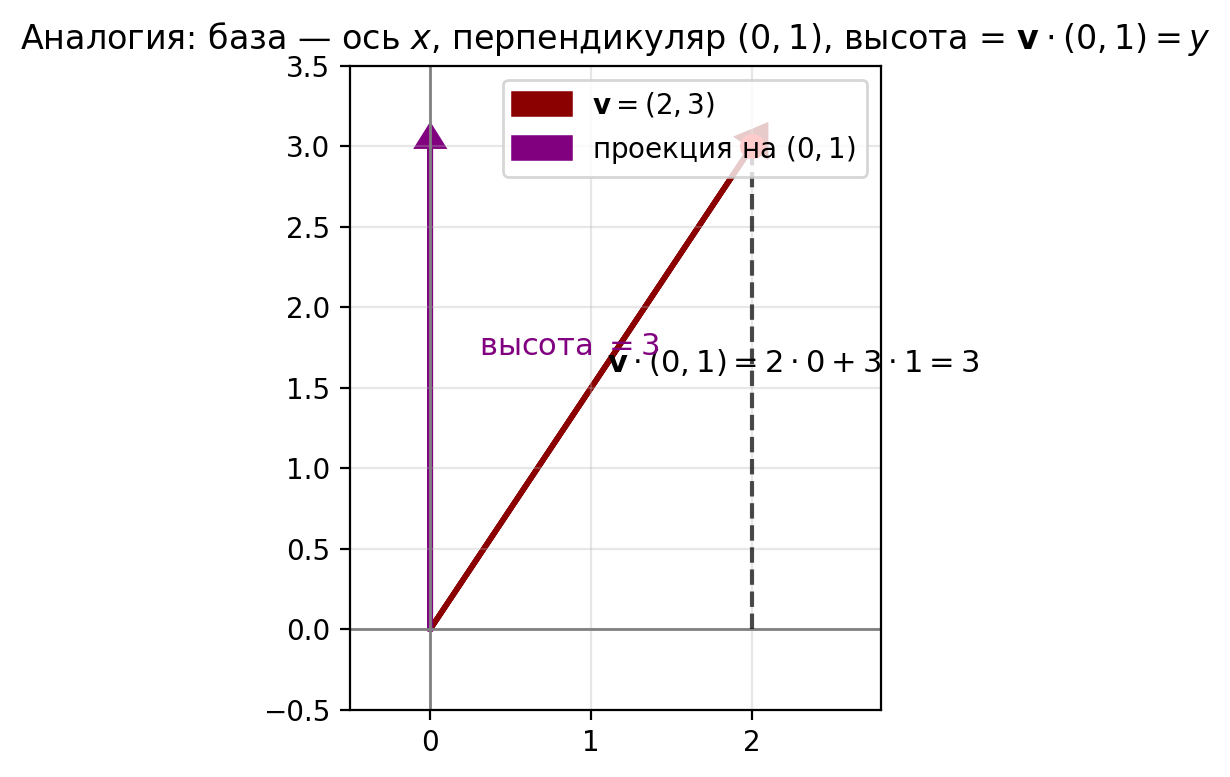

In [55]:
# Простая аналогия: база = ось x, перпендикуляр = (0,1), высота = y-координата
v = np.array([2.0, 3.0])
ex = np.array([1.0, 0.0])
ey = np.array([0.0, 1.0])
h_signed = np.dot(v, ey)  # = 3
proj_on_ey = h_signed * ey

fig, ax = plt.subplots(1, 1, figsize=(5, 4))
ax.axhline(0, color='gray', linewidth=1)
ax.axvline(0, color='gray', linewidth=1)
ax.arrow(0, 0, v[0], v[1], head_width=0.2, head_length=0.15, fc='darkred', ec='darkred', linewidth=2, label=r'$\mathbf{v}=(2,3)$')
ax.arrow(0, 0, proj_on_ey[0], proj_on_ey[1], head_width=0.15, head_length=0.12, fc='purple', ec='purple', linewidth=2, label=r'проекция на $(0,1)$')
ax.plot([v[0], v[0]], [0, v[1]], 'k--', alpha=0.7)
ax.plot(v[0], v[1], 'ro', markersize=8)
ax.text(1.1, 1.6, r'$\mathbf{v}\cdot(0,1)=2\cdot 0+3\cdot 1=3$', fontsize=11)
ax.text(0.3, 1.7, r'высота $=3$', fontsize=11, color='purple')
ax.set_aspect('equal')
ax.set_xlim(-0.5, 2.8)
ax.set_ylim(-0.5, 3.5)
ax.legend(loc='upper right')
ax.set_title(r'Аналогия: база — ось $x$, перпендикуляр $(0,1)$, высота = $\mathbf{v}\cdot(0,1)=y$')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Картинка: почему высота = $\mathbf{v}_2 \cdot \mathbf{n}$

Ниже показаны вектор $\mathbf{v}_2$, единичный перпендикуляр $\mathbf{n}$ к $\mathbf{v}_1$ и **проекция** $\mathbf{v}_2$ на направление $\mathbf{n}$. Эта проекция — вектор $(\mathbf{v}_2 \cdot \mathbf{n})\,\mathbf{n}$ (фиолетовый). Его длина:
$$|(\mathbf{v}_2 \cdot \mathbf{n})\,\mathbf{n}| = |\mathbf{v}_2 \cdot \mathbf{n}| \cdot |\mathbf{n}| = |\mathbf{v}_2 \cdot \mathbf{n}| \cdot 1 = |\mathbf{v}_2 \cdot \mathbf{n}|,$$
то есть скалярное произведение (по модулю) и есть длина перпендикуляра — высота. Поэтому (ориентированная) высота $h = \mathbf{v}_2 \cdot \mathbf{n}$.

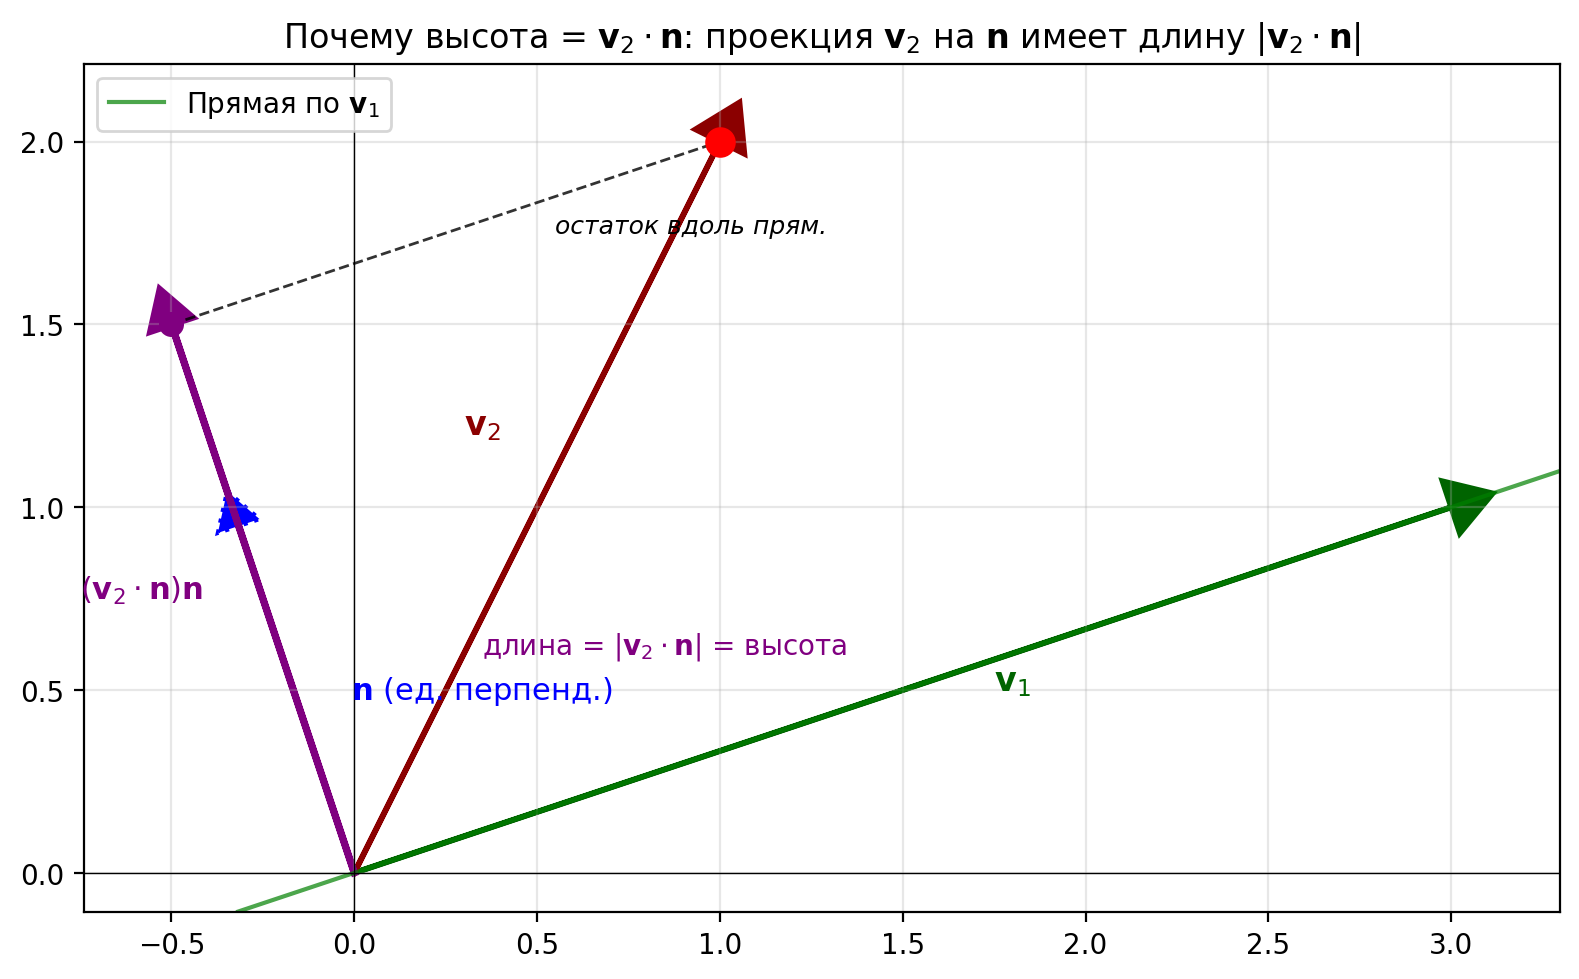

In [56]:
# Рисунок: скалярное произведение v2·n и длина перпендикуляра (высота)
a, b, c, d = 3.0, 1.0, 1.0, 2.0
v1 = np.array([a, c])
v2 = np.array([b, d])
n = np.array([-c, a]) / np.linalg.norm(v1)   # единичный перпендикуляр к v1
v2_dot_n = np.dot(v2, n)                       # число: проекция v2 на n
proj_v2_on_n = v2_dot_n * n                    # вектор проекции (высота по направлению n)
# Нога перпендикуляра: проекция v2 на v1
t = np.dot(v2, v1) / np.dot(v1, v1)
foot = t * v1

fig, ax = plt.subplots(1, 1, figsize=(8, 6))
# Прямая по v1 (основание)
ax.axline((0, 0), v1, color='green', linewidth=1.5, alpha=0.7, label=r'Прямая по $\mathbf{v}_1$')
# Вектор v1
ax.arrow(0, 0, v1[0], v1[1], head_width=0.15, head_length=0.12, fc='darkgreen', ec='darkgreen', linewidth=2)
# Вектор v2
ax.arrow(0, 0, v2[0], v2[1], head_width=0.15, head_length=0.12, fc='darkred', ec='darkred', linewidth=2)
# Единичный перпендикуляр n (от начала)
ax.arrow(0, 0, n[0], n[1], head_width=0.12, head_length=0.1, fc='blue', ec='blue', linewidth=1.5, linestyle=':')
# Проекция v2 на n: вектор (v2·n)*n — это и есть «высота» по направлению n
ax.arrow(0, 0, proj_v2_on_n[0], proj_v2_on_n[1], head_width=0.12, head_length=0.1, fc='purple', ec='purple', linewidth=2.5)
# Точка — конец v2; пунктиром от проекции до v2 (остаток вдоль v1)
ax.plot([proj_v2_on_n[0], v2[0]], [proj_v2_on_n[1], v2[1]], 'k--', linewidth=1, alpha=0.8)
ax.plot(v2[0], v2[1], 'ro', markersize=10)
ax.plot(proj_v2_on_n[0], proj_v2_on_n[1], 'o', color='purple', markersize=8)

ax.text(v1[0]/2 + 0.25, v1[1]/2, r'$\mathbf{v}_1$', fontsize=12, color='darkgreen')
ax.text(v2[0]/2 - 0.2, v2[1]/2 + 0.2, r'$\mathbf{v}_2$', fontsize=12, color='darkred')
ax.text(n[0]/2 + 0.15, n[1]/2, r'$\mathbf{n}$ (ед. перпенд.)', fontsize=11, color='blue')
ax.text(proj_v2_on_n[0]/2 - 0.5, proj_v2_on_n[1]/2, r'$(\mathbf{v}_2\cdot\mathbf{n})\mathbf{n}$', fontsize=11, color='purple')
ax.text(proj_v2_on_n[0]/2 + 0.6, proj_v2_on_n[1]/2 - 0.15, r'длина = $|\mathbf{v}_2\cdot\mathbf{n}|$ = высота', fontsize=10, color='purple')
ax.text((proj_v2_on_n[0]+v2[0])/2 + 0.3, (proj_v2_on_n[1]+v2[1])/2, 'остаток вдоль прям.', fontsize=9, style='italic')
ax.set_aspect('equal')
ax.axhline(0, color='k', linewidth=0.5)
ax.axvline(0, color='k', linewidth=0.5)
ax.legend(loc='upper left')
ax.grid(True, alpha=0.3)
ax.set_title(r'Почему высота = $\mathbf{v}_2\cdot\mathbf{n}$: проекция $\mathbf{v}_2$ на $\mathbf{n}$ имеет длину $|\mathbf{v}_2\cdot\mathbf{n}|$')
plt.tight_layout()
plt.show()

Другой способ: параллелограмм можно разрезать **диагональю** на два треугольника. Каждый треугольник имеет площадь $\frac{1}{2}|ad - bc|$. Поэтому площадь параллелограмма = $|ad - bc|$.

**Почему каждый треугольник — именно $\frac{1}{2}|ad - bc|$?** Диагональ из $\mathbf{0}$ в $\mathbf{v}_1+\mathbf{v}_2$ делит параллелограмм на два треугольника равной площади (они симметричны относительно середины диагонали). Площадь параллелограмма мы уже нашли: $|\det A| = |ad - bc|$. Значит, на каждый треугольник приходится половина: $\frac{1}{2}|ad - bc|$. То же можно получить по формуле «площадь треугольника со сторонами $\mathbf{v}_1$, $\mathbf{v}_2$» = $\frac{1}{2}|\det(\mathbf{v}_1,\mathbf{v}_2)| = \frac{1}{2}|ad - bc|$.



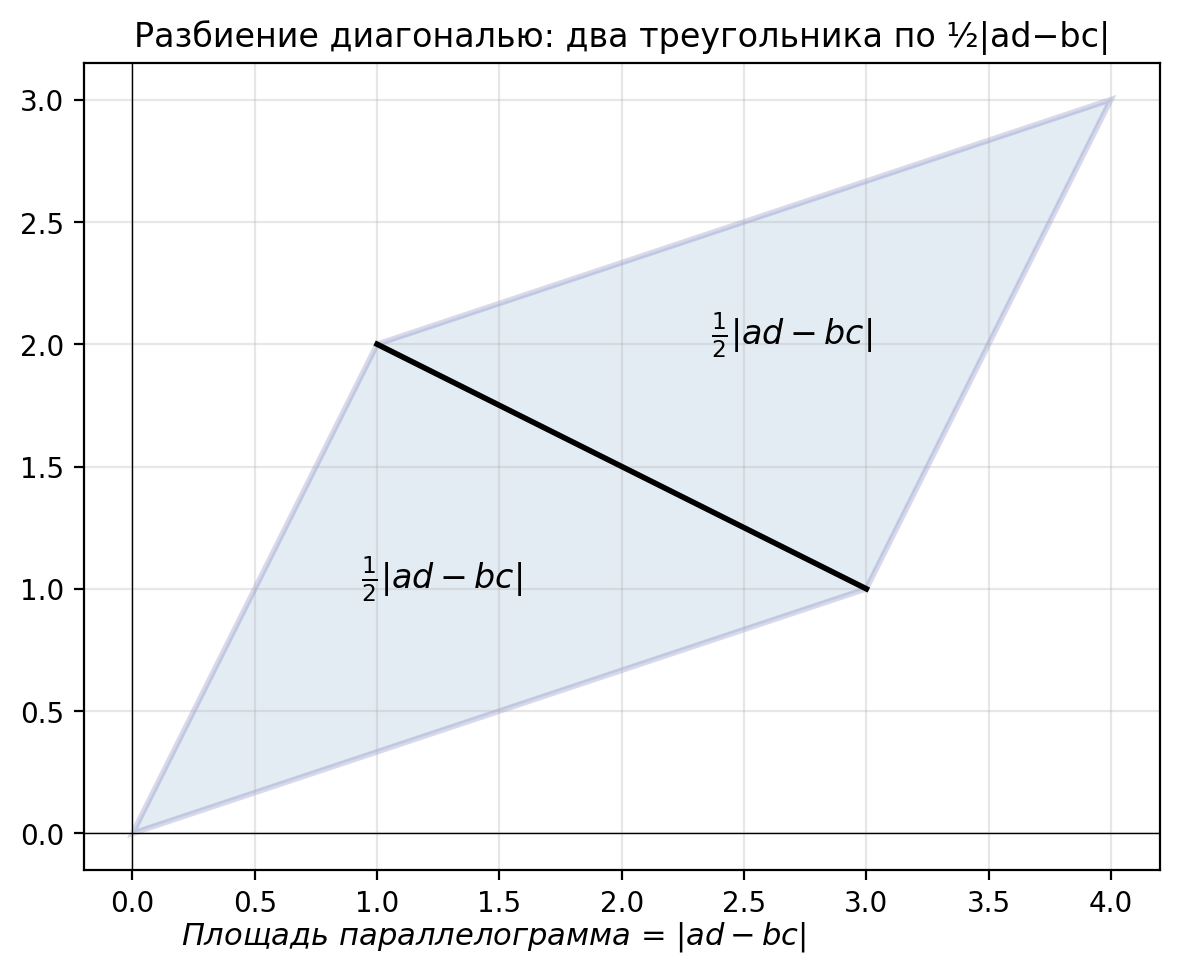

In [57]:
# Разбиение на два треугольника (площадь каждого = ½|ad - bc|)
fig, ax = plt.subplots(1, 1, figsize=(6, 5))
para = np.array([[0, 0], v1, v1+v2, v2, [0, 0]])
ax.fill(para[:, 0], para[:, 1], alpha=0.15, color='steelblue', edgecolor='navy', linewidth=2)
# Диагональ (v1 -> v2)
ax.plot([v1[0], v2[0]], [v1[1], v2[1]], 'k-', linewidth=2)
# Подписи площадей
ax.text(v1[0]/3 + v2[0]/3 - 0.4, v1[1]/3 + v2[1]/3, r'$\frac{1}{2}|ad-bc|$', fontsize=12)
ax.text((v1[0]+v2[0])/2 + (v1+v2)[0]/3 * 0.5 - 0.3, (v1[1]+v2[1])/2 + (v1+v2)[1]/3 * 0.5, r'$\frac{1}{2}|ad-bc|$', fontsize=12)
ax.text(0.2, -0.45, r'Площадь параллелограмма = $|ad - bc|$', fontsize=11, style='italic')
ax.set_aspect('equal')
ax.axhline(0, color='k', linewidth=0.5)
ax.axvline(0, color='k', linewidth=0.5)
ax.grid(True, alpha=0.3)
ax.set_title('Разбиение диагональю: два треугольника по ½|ad−bc|')
plt.tight_layout()
plt.show()

## 1. Квадрат без смещения (масштабирование)

Матрица диагональная: растяжение/сжатие по осям. Единичный квадрат остаётся квадратом.  
Пример: $A = \begin{pmatrix} k & 0 \\ 0 & k \end{pmatrix}$ — масштаб в $k$ раз. Тогда $\det A = k^2$ — площадь образа равна $k^2$.

Матрица A (масштаб k=2.0):
[[2. 0.]
 [0. 2.]]
det(A) = 4.0   (площадь образа квадрата 1×1 равна 4.0 )


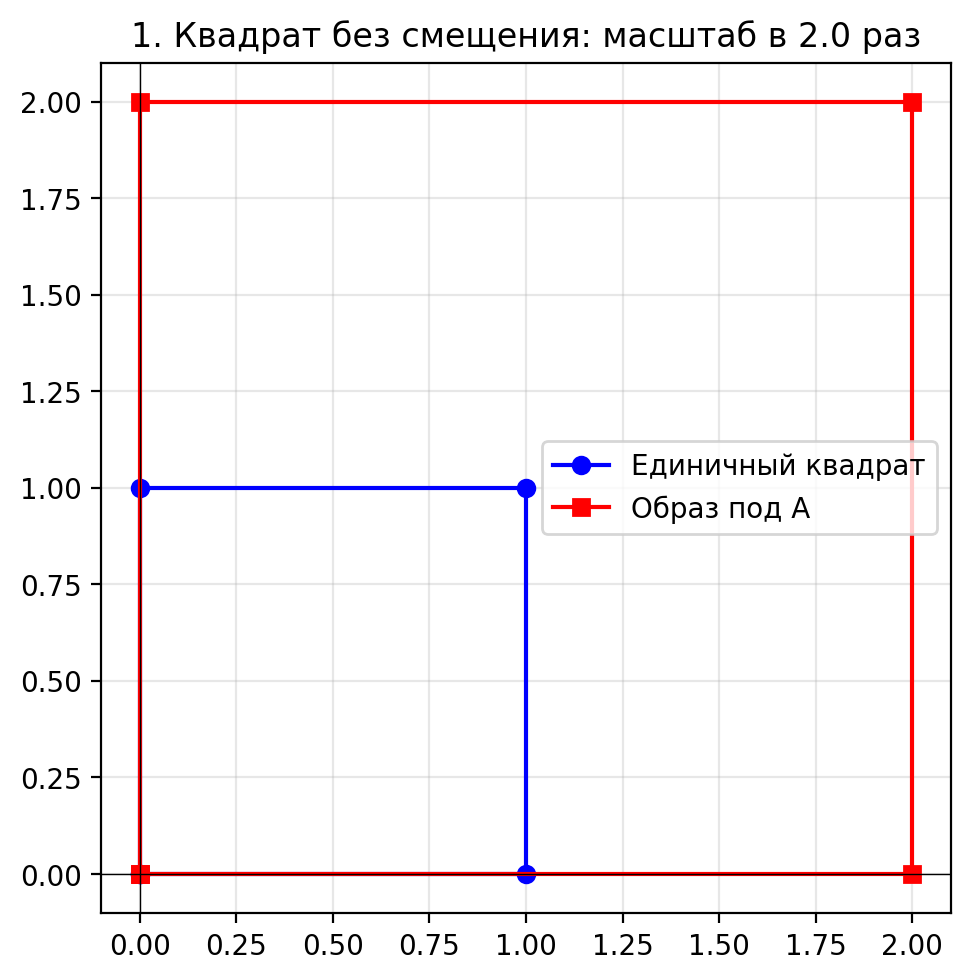

In [58]:
# Масштаб: квадрат просто увеличивается (без смещения)
k = 2.0
A1 = np.array([[k, 0],
               [0, k]])
print("Матрица A (масштаб k={}):".format(k))
print(A1)
print("det(A) =", det2(A1), "  (площадь образа квадрата 1×1 равна", det2(A1), ")")
fig, ax = plt.subplots(1, 1, figsize=(5, 5))
plot_unit_square_and_image(A1, "1. Квадрат без смещения: масштаб в {} раз".format(k), ax=ax)
plt.show()

## 2. Смещение по одной оси (сдвиг вдоль одной оси)

Матрица сдвига (shear): например $A = \begin{pmatrix} 1 & s \\ 0 & 1 \end{pmatrix}$ — сдвиг по горизонтали, или $\begin{pmatrix} 1 & 0 \\ s & 1 \end{pmatrix}$ — по вертикали. Параллелограмм, но основание остаётся отрезком по оси. $\det A = 1$ — площадь сохраняется.

Матрица A (сдвиг по оси x, s=0.8):
[[1.  0.8]
 [0.  1. ]]
det(A) = 1.0


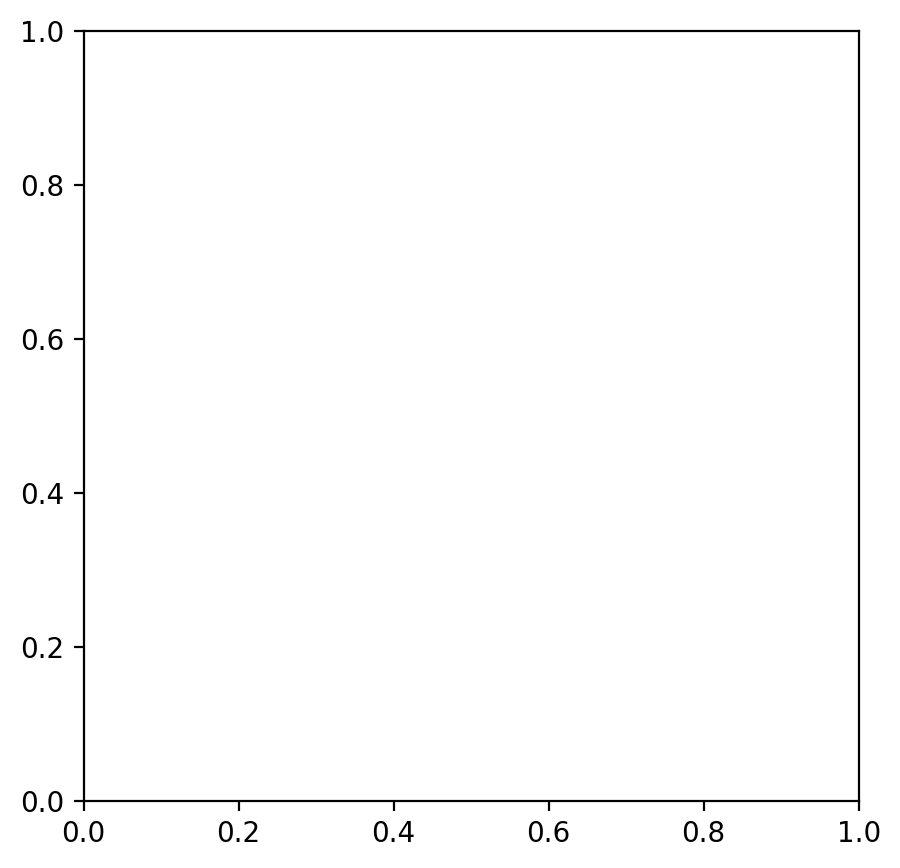

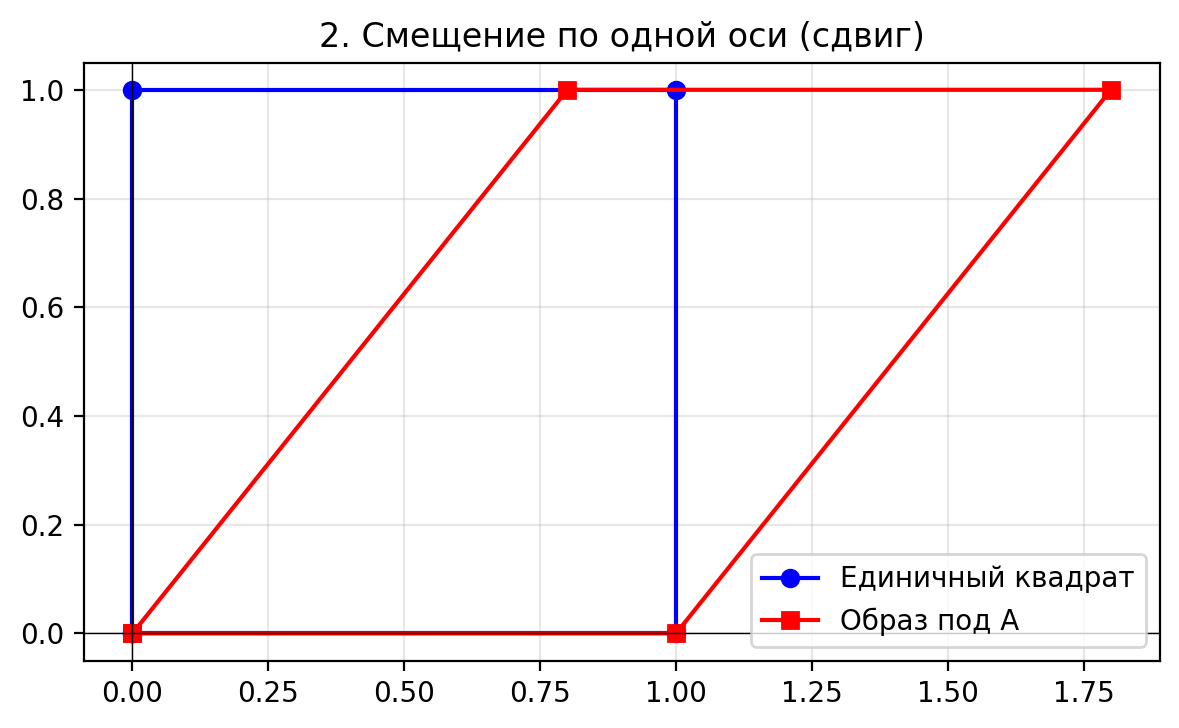

In [59]:
# Сдвиг по одной оси (например, по горизонтали)
s = 0.8
A2 = np.array([[1, s],
               [0, 1]])
print("Матрица A (сдвиг по оси x, s={}):".format(s))
print(A2)
print("det(A) =", det2(A2))
fig, ax = plt.subplots(1, 1, figsize=(5, 5))
plot_unit_square_and_image(A2, "2. Смещение по одной оси (сдвиг)")
plt.show()

## 3. Смещение по обеим осям (общая матрица 2×2)

Матрица с ненулевыми недиагональными элементами: образ единичного квадрата — произвольный параллелограмм. Вычисляем детерминант по формуле $ad - bc$ и проверяем, что площадь образа совпадает с $|\det A|$.

Матрица A (смещение по обеим осям):
[[1.2 0.4]
 [0.3 1.1]]
det(A) = 1.2000000000000002


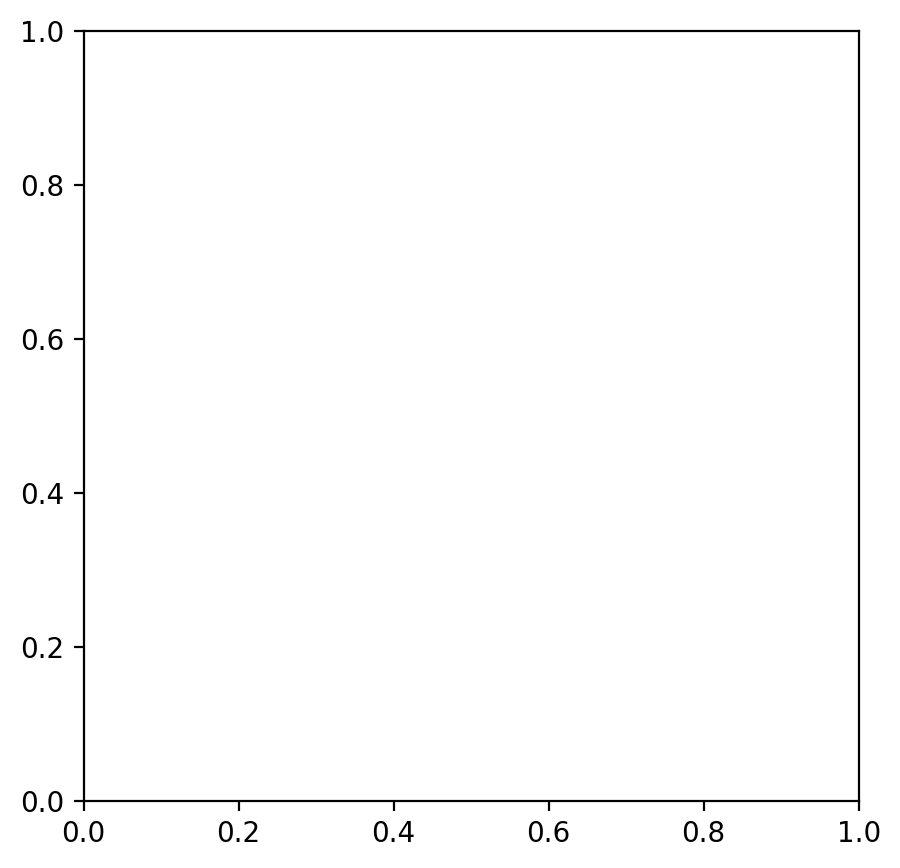

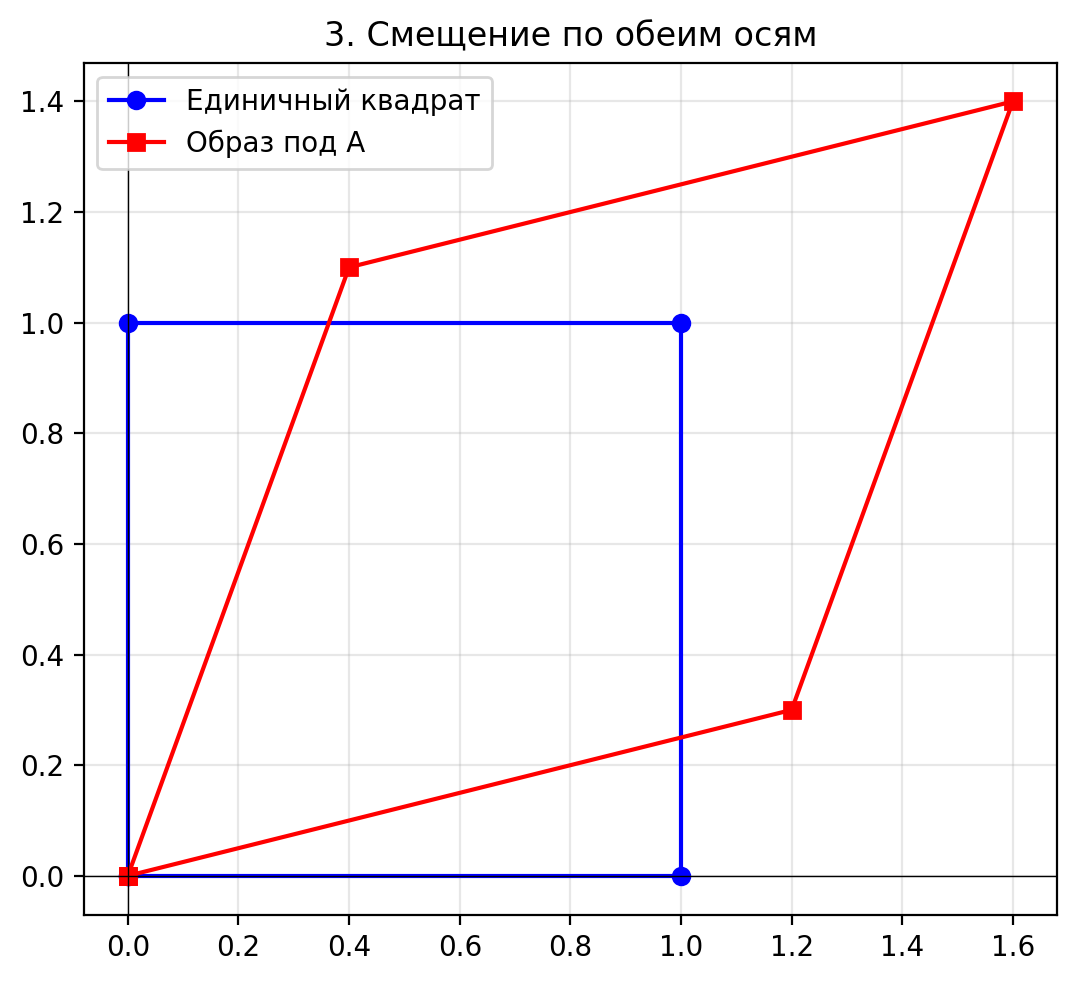

In [60]:
# Общая матрица 2×2: смещение по обеим осям
A3 = np.array([[1.2, 0.4],
               [0.3, 1.1]])
print("Матрица A (смещение по обеим осям):")
print(A3)
print("det(A) =", det2(A3))
fig, ax = plt.subplots(1, 1, figsize=(5, 5))
plot_unit_square_and_image(A3, "3. Смещение по обеим осям")
plt.show()

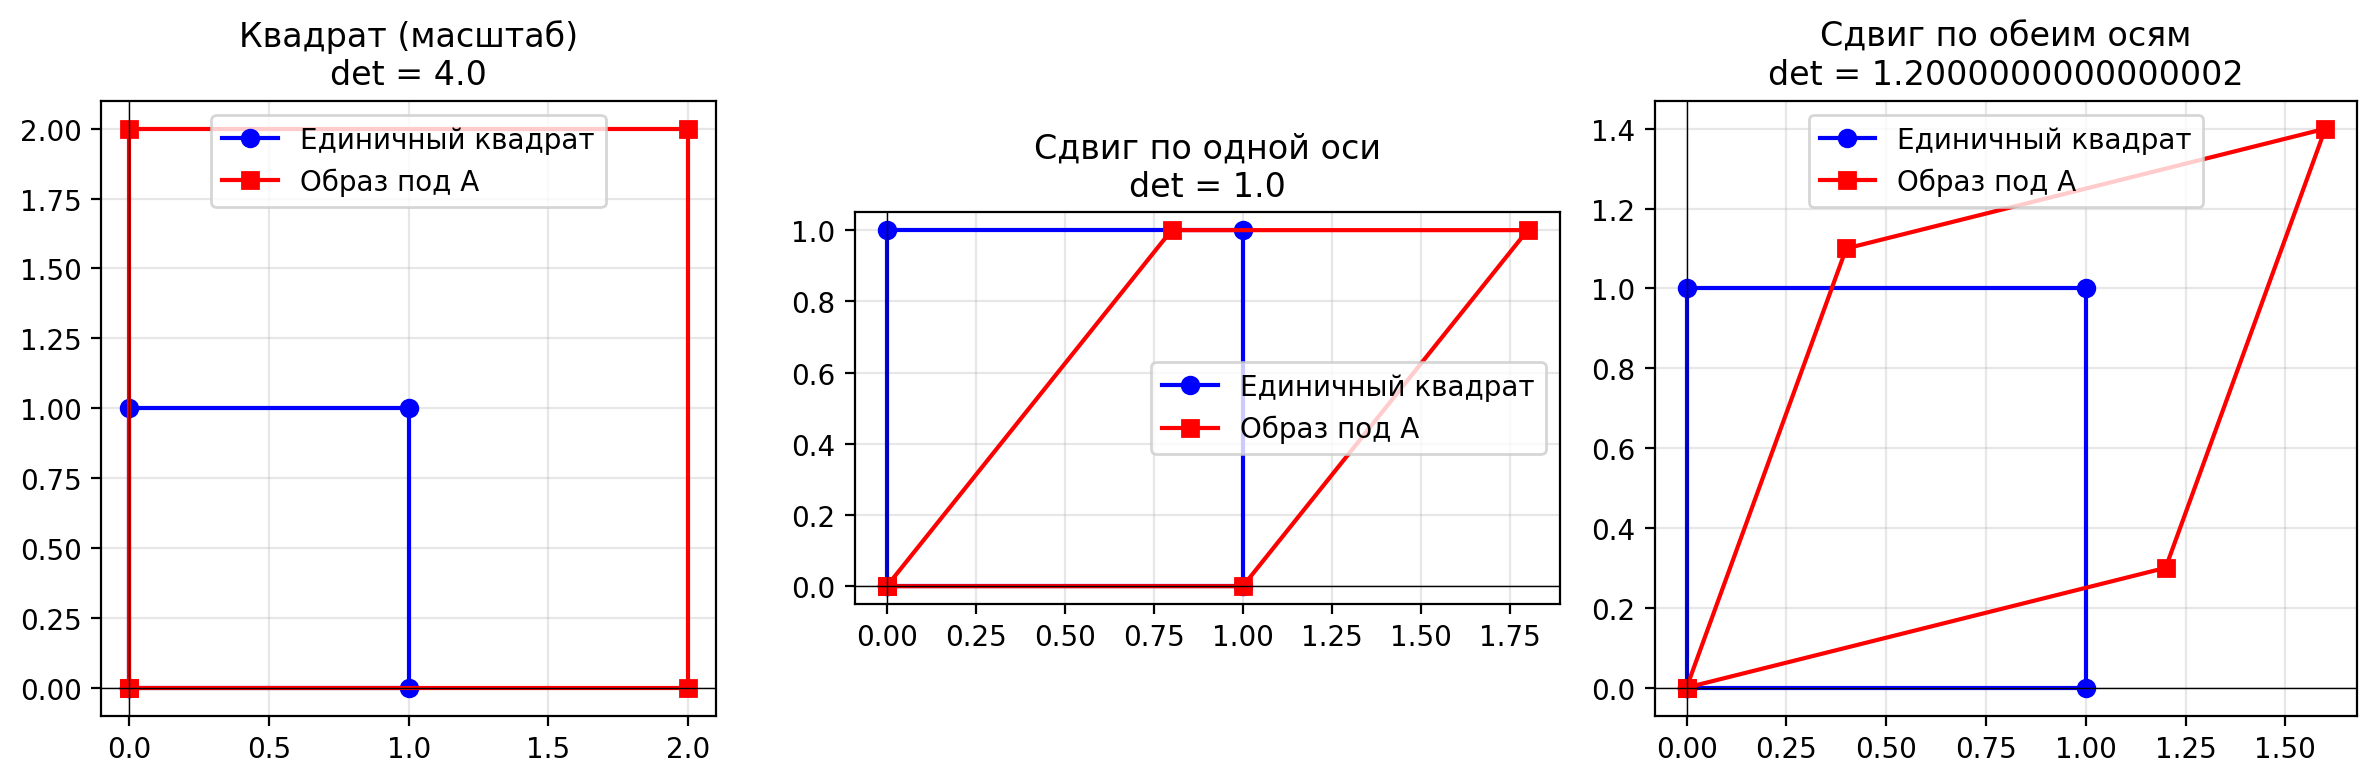

In [61]:
# Сводка: все три случая в одном рисунке
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
k, s = 2.0, 0.8
A1 = np.array([[k, 0], [0, k]])
A2 = np.array([[1, s], [0, 1]])
A3 = np.array([[1.2, 0.4], [0.3, 1.1]])
for ax, A, label in zip(axes, [A1, A2, A3], ["Квадрат (масштаб)", "Сдвиг по одной оси", "Сдвиг по обеим осям"]):
    plot_unit_square_and_image(A, f"{label}\ndet = {det2(A)}", ax=ax)
plt.tight_layout()
plt.show()

**Итог:** Детерминант матрицы 2×2 равен (ориентированной) площади параллелограмма, в который переходит единичный квадрат под действием этой матрицы. Формула $\det A = ad - bc$ даёт именно эту площадь (с учётом знака ориентации).